# 05 · Robustness

576 specifications, all persisted. Nothing here is a favourable subset.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from deadcat import data as D, plotting as P
from deadcat.config import load_config
P.use_style(); pd.set_option("display.width", 180)
cfg = load_config(ROOT / "configs" / "default.yaml")
T = ROOT / "results" / "tables"; M = ROOT / "results" / "metrics"
print("config fingerprint:", cfg.fingerprint)

config fingerprint: a9ca33aed3d9


In [2]:
grid = pd.read_csv(T / "robustness_grid.csv")
print(f"{len(grid):,} specifications")
print(json.dumps(json.load(open(M / "robustness.json"))["car_h20_across_specs"], indent=2))

576 specifications
{
  "n": 48,
  "min": -0.005598976559893647,
  "max": -0.0014894456388321444,
  "median": -0.0031552273021531415,
  "share_negative": 1.0,
  "share_negative_and_significant": 0.5,
  "share_positive_and_significant": 0.0
}


## Is the sign ever positive?

In [3]:
h = grid[grid.horizon == cfg.outcomes.primary_horizon]\
        .drop_duplicates(["z_threshold", "vol_window", "cooldown"])
print(f"negative mean CAR:            {int((h.mean_car < 0).sum())} / {len(h)}")
print(f"significantly negative:       {int(((h.mean_car < 0) & (h.p_value < .05)).sum())} / {len(h)}")
print(f"significantly positive:       {int(((h.mean_car > 0) & (h.p_value < .05)).sum())} / {len(h)}")
print(f"recovery rate below 50%:      {int((h.recovery_rate < .5).sum())} / {len(h)}")

negative mean CAR:            48 / 48
significantly negative:       24 / 48
significantly positive:       0 / 48
recovery rate below 50%:      48 / 48


## Severity makes it worse, not better

In [4]:
display((h.groupby("z_threshold")[["mean_car", "recovery_rate"]]
         .agg(["median", "min", "max"]) * 100).round(3))

mean_car               recovery_rate                
              median    min    max        median     min     max
z_threshold                                                     
-4.0          -0.492 -0.560 -0.404        46.528  46.321  46.755
-3.5          -0.363 -0.432 -0.302        46.904  46.573  47.184
-3.0          -0.258 -0.320 -0.202        47.199  47.088  47.728
-2.5          -0.189 -0.231 -0.149        47.883  47.515  48.215

## Sign consistency of the conditional effects

In [5]:
print(f"AVOL Q4 > Q1 holds in            {(grid.diff_avol_q4_minus_q1 > 0).mean():.1%} of specs")
print(f"broad < idiosyncratic holds in   {(grid.diff_broad_minus_idio < 0).mean():.1%} of specs")
print("\nThe volume effect is directionally stable but never significant;")
print("the crash-type contrast is a coin flip - consistent with a true null.")

AVOL Q4 > Q1 holds in            97.9% of specs
broad < idiosyncratic holds in   66.7% of specs

The volume effect is directionally stable but never significant;
the crash-type contrast is a coin flip - consistent with a true null.


## The full grid

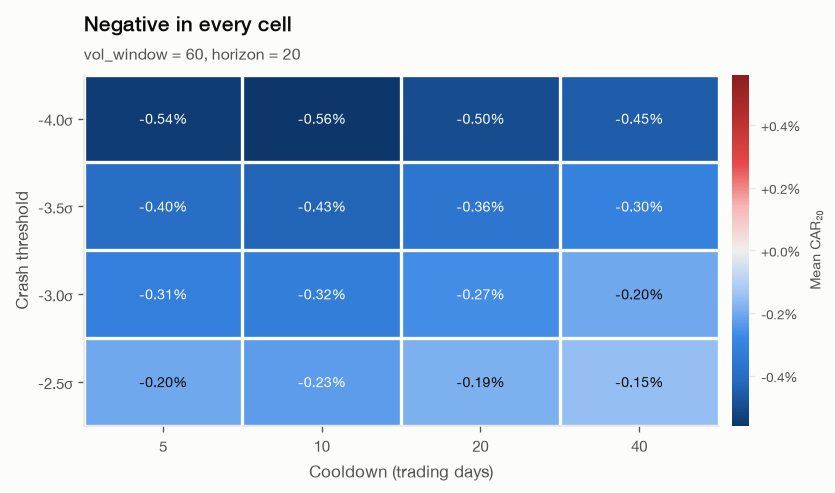

In [6]:
piv = (h[h.vol_window == cfg.events.vol_window]
       .pivot(index="z_threshold", columns="cooldown", values="mean_car"))
piv.index = [f"{i:.1f}σ" for i in piv.index]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
P.heatmap(ax, piv, P.CMAP_DIV, norm=P.diverging_norm(piv.values),
          cbar_label="Mean CAR₂₀")
ax.set_xlabel("Cooldown (trading days)"); ax.set_ylabel("Crash threshold")
P.finish(fig, ax, "Negative in every cell",
         f"vol_window = {cfg.events.vol_window}, horizon = 20")
plt.show()

## Conclusion

The absence of a dead-cat bounce is not an artefact of the crash threshold, the volatility window, the cooldown, the horizon or the definition of a high-VIX regime.